# Correlation Dimension of Stanford Encyclopedia of Philosophy

This notebook demonstrates how to compute the correlation dimension of texts using the `corrdim` library.

We provide two examples:
1. **High-level interface**: Simple one-line computation
2. **Low-level interface**: More control for custom use cases

To be able to run the code, you need a GPU with at least 13GB memory.

## Example 1: High-Level Interface

The simplest way to compute correlation dimension - just one line of code!

In [1]:
# Setup: import libraries and disable gradient computation
import sys
sys.path.append('..')
import torch
import matplotlib.pyplot as plt
import corrdim

torch.set_grad_enabled(False)  # We don't need gradients for inference

/ssdfs/datahome/u26045/projects/corrdimlib/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

### Step 1: Load texts

Load articles from the Stanford Encyclopedia of Philosophy (SEP) dataset.

In [2]:
import os

# Load all articles from the data folder
texts = {}
data_dir = "../data/sep60"
for filename in os.listdir(data_dir):
    filepath = os.path.join(data_dir, filename)
    with open(filepath, "r") as f:
        lines = []
        for line in f:
            lines.append(line.strip())
        texts[filename] = ' '.join(lines)

print(f"Loaded {len(texts)} articles")

Loaded 60 articles


### Step 2: Compute correlation dimensions

For each article, we:
- Use the first 10,000 tokens
- Apply dimension reduction to 8192 (to save GPU memory)
- Compute the correlation dimension with a single function call

In [3]:
corrdim.set_corrint_backend("triton")

'triton'

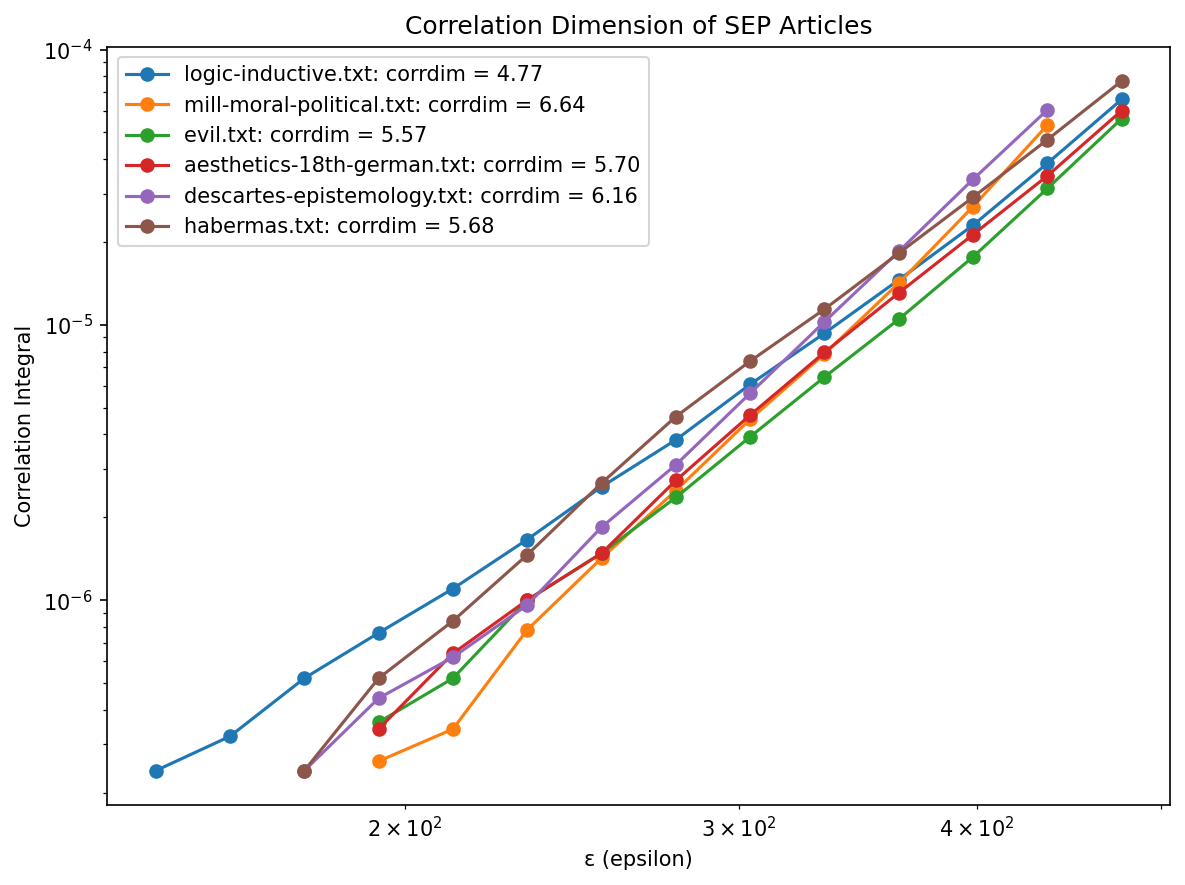

In [5]:
# Plot results for multiple articles
fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=150)

# Process first 6 articles as an example
max_articles = 6
for i, (filename, text) in enumerate(texts.items()):
    if i >= max_articles:
        break
    
    result = corrdim.measure_text(
        text,
        model='Qwen/Qwen2.5-1.5B',
        precision=torch.float16,
        truncation_tokens=10000,
        dim_reduction=8192,
    )
    
    # Plot the correlation integral curve
    ax.plot(result.epsilons_linear_region, result.corrints_linear_region,
            '-o',
            label=f'{filename}: corrdim = {result.corrdim:.2f}')

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ε (epsilon)")
ax.set_ylabel("Correlation Integral")
ax.set_title("Correlation Dimension of SEP Articles")
ax.legend()
plt.tight_layout()
plt.show()

---

## Example 2: Low-Level Interface

For more control, you can compute correlation dimension from log-probabilities directly.
This example also demonstrates using an AWQ-quantized model (Qwen2.5-7B-Instruct-AWQ) which provides
better performance with reduced memory usage compared to full precision models.


This example requires the library `autoawq` to be installed.
If you find it difficult to install, just use another model that requires no quantization libraries.

In [6]:
# Import required libraries
import torch
import transformers
import matplotlib.pyplot as plt
import corrdim

### Step 1: Load model and text

Load a model

In [7]:
# Load AWQ-quantized model and tokenizer
model_name = "Qwen/Qwen2.5-1.5B"
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
).to("cuda")
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

# Load a single article as example
with open("../data/sep60/chaos.txt", "r") as f:
    lines = []
    for line in f:
        lines.append(line.strip())
    text = ' '.join(lines)

### Step 2: Compute log-probabilities

Get log-probability vectors for each token using the AWQ-quantized model.

**Note**: Without dimension reduction, the full vocabulary is very large, so we use 3,000 tokens here to manage memory.

In [8]:
# Tokenize and get model outputs
max_tokens = 3000
inputs = tokenizer(text, max_length=max_tokens, truncation=True, return_tensors="pt").to("cuda")
outputs = model(**inputs)
logits = outputs.logits[0]

# Convert to log-probabilities: shape is [sequence_length, vocab_size]
logprobs = logits.log_softmax(-1)
print(f"Log-probabilities shape: {logprobs.shape}")
print(f"Vocabulary size: {logprobs.shape[1]}")

logprobs = corrdim.reduce_dimension(logprobs, num_groups=8192)
print(f"Reduced log-probabilities shape: {logprobs.shape}")

Log-probabilities shape: torch.Size([3000, 151936])
Vocabulary size: 151936
Reduced log-probabilities shape: torch.Size([3000, 8192])


### Step 3: Compute correlation integral

Calculate correlation integral values for a range of epsilon (distance threshold) values.

In [9]:
# Define a range of epsilon values (distance thresholds)
epsilons = torch.logspace(-20, 20, 10000, device="cuda")

# Compute correlation integral for each epsilon
curve = corrdim.curve_from_vectors(logprobs)

### Step 4: Estimate correlation dimension

Fit the correlation dimension from the correlation integral curve.

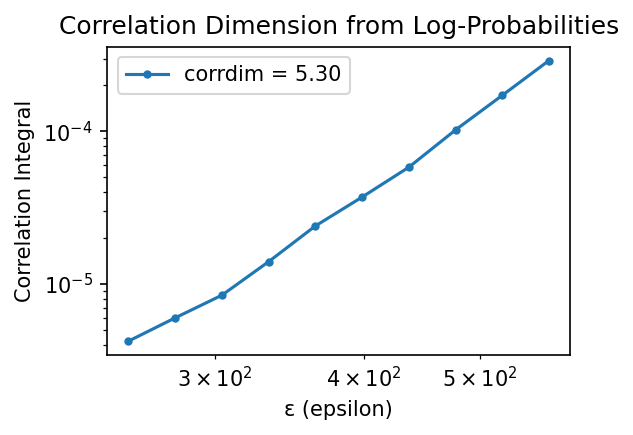

In [10]:
# Our custom implementation: compute correlation dimension from the curve
result = corrdim.estimate_dimension_from_curve(
    curve=curve,
    correlation_integral_range="auto",
)

# Plot the results
fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=150)
ax.plot(result.epsilons_linear_region, result.corrints_linear_region, '.-',
        label=f"corrdim = {result.corrdim:.2f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("ε (epsilon)")
ax.set_ylabel("Correlation Integral")
ax.set_title("Correlation Dimension from Log-Probabilities")
ax.legend()
plt.tight_layout()
plt.show()

# Example 3: See how corrdim changes alongside a text

In [11]:
# Import required libraries
import torch
import transformers
import matplotlib.pyplot as plt
import corrdim

### Step 1: Load model and text

In [12]:
# Load model and tokenizer
model_name = "Qwen/Qwen2.5-1.5B"
model = transformers.AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
).to("cuda")
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

# Load a single article as example
with open("../data/sep60/chaos.txt", "r") as f:
    lines = []
    for line in f:
        lines.append(line.strip())
    text = ' '.join(lines)

### Step 2: Compute log-probabilities

Get log-probability vectors for each token.

**Note**: Without dimension reduction, the full vocabulary is very large, so we use 3,000 tokens here to manage memory.

In [13]:
# Tokenize and get model outputs
max_tokens = 10000
inputs = tokenizer(text, max_length=max_tokens, truncation=True, return_tensors="pt").to("cuda")
outputs = model(**inputs)
logits = outputs.logits[0]

# Convert to log-probabilities: shape is [sequence_length, vocab_size]
logprobs = logits.log_softmax(-1)
print(f"Log-probabilities shape: {logprobs.shape}")
print(f"Vocabulary size: {logprobs.shape[1]}")

logprobs = corrdim.reduce_dimension(logprobs, num_groups=8192)
print(f"Reduced log-probabilities shape: {logprobs.shape}")

Log-probabilities shape: torch.Size([10000, 151936])
Vocabulary size: 151936
Reduced log-probabilities shape: torch.Size([10000, 8192])


### Step 3: Compute correlation integrals for all prefixes of the token sequence

In [14]:
# Define a range of epsilon values (distance thresholds)
epsilons = torch.logspace(-20, 20, 10000, device="cuda")

# Use "progressive" version of correlation_integral to compute for all prefixes
corrints_arr = corrdim.progressive_correlation_integral(logprobs, epsilons)

### Step 4: Estimate correlation dimension for each prefix

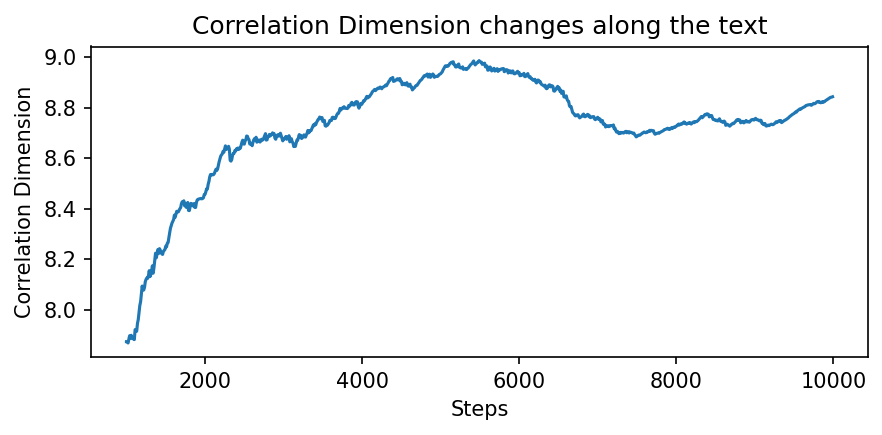

In [ ]:
# Our custom implementation: compute correlation dimension from the curve
fig, ax = plt.subplots(1, 1, figsize=(6, 3), dpi=150)

epsilon_range=(500, 1200)       # <-- This would change the value of corrdim
colormap = plt.get_cmap("coolwarm")

xs = []
ys = []
for i in range(1000, max_tokens, 10):      # Skip first 1000 tokens 
    corrints = corrints_arr[i]
    result = corrdim.estimate_dimension_from_curve(
        curve=corrdim.CurveResult(
            epsilons=epsilons.cpu().numpy(), 
            corrints=corrints.cpu().numpy(), 
            sequence_length=logprobs.shape[0],
        ),
        correlation_integral_range=None,
        epsilon_range=epsilon_range,
    )
    xs.append(i)
    ys.append(result.corrdim)

plt.plot(xs, ys)

ax.set_xlabel("Steps")
ax.set_ylabel("Correlation Dimension")
ax.set_title("Correlation Dimension changes along the text")
plt.tight_layout()
plt.show()